<a href="https://colab.research.google.com/github/dmitrijprilepa/pattern-recognition-practice/blob/main/notebooks/PR02_Prylepa_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 2

## Дослідницький аналіз і підготовка даних

**Дисципліна:** Розпізнавання образів і машинне навчання  
**Студент:** <прізвище, ім’я>  
**Група:** <назва групи>  
**Дата виконання:** <дата>

### Мета роботи

Навчитися аналізувати якість табличних даних, виявляти та
виправляти пропуски, дублікати, неправильні типи й аномальні
значення, кодувати категоріальні ознаки та формувати навчальну
і тестову вибірки.


## 1. Підключення бібліотек

Підключаються бібліотеки для роботи з таблицями, числовими даними,
візуалізацією, збереженням метаданих і формуванням train/test-вибірок.


In [97]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from IPython.display import display


In [98]:
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1


## 2. Підключення Google Drive
Google Drive використовується для читання початкових даних і
збереження результатів очищення.


In [99]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

SOURCE_PATH = DATA_DIR / "iris.csv"
DIRTY_PATH = DATA_DIR / "iris_dirty.csv"
CLEANED_PATH = PROCESSED_DIR / "iris_cleaned.csv"

X_TRAIN_PATH = PROCESSED_DIR / "X_train.csv"
X_TEST_PATH = PROCESSED_DIR / "X_test.csv"
Y_TRAIN_PATH = PROCESSED_DIR / "y_train.csv"
Y_TEST_PATH = PROCESSED_DIR / "y_test.csv"

SUMMARY_PATH = REPORTS_DIR / "preprocessing_summary.csv"
CLASS_MAPPING_PATH = REPORTS_DIR / "class_mapping.json"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Папка проєкту:", PROJECT_DIR)
print("Папка початкових даних:", DATA_DIR)
print("Папка підготовлених даних:", PROCESSED_DIR)
print("Папка звітів:", REPORTS_DIR)


Папка проєкту: /content/drive/MyDrive/pattern-recognition-practice
Папка початкових даних: /content/drive/MyDrive/pattern-recognition-practice/data
Папка підготовлених даних: /content/drive/MyDrive/pattern-recognition-practice/data/processed
Папка звітів: /content/drive/MyDrive/pattern-recognition-practice/reports


## 3. Завантаження початкового набору Iris

Спочатку перевіряється наявність файла `iris.csv`, створеного у
практичній роботі 1. Якщо файл відсутній, він створюється повторно.


In [101]:
if SOURCE_PATH.exists():
    source_df = pd.read_csv(SOURCE_PATH)
    print("Початковий файл завантажено з Google Drive.")
else:
    print("Файл iris.csv не знайдено. Створюємо його повторно.")

    iris = load_iris(as_frame=True)
    source_df = iris.frame.copy()

    source_df["species"] = source_df["target"].map(
        {
            0: "setosa",
            1: "versicolor",
            2: "virginica"
        }
    )

    source_df = source_df.drop(columns=["target"])

    source_df = source_df.rename(
        columns={
            "sepal length (cm)": "sepal_length_cm",
            "sepal width (cm)": "sepal_width_cm",
            "petal length (cm)": "petal_length_cm",
            "petal width (cm)": "petal_width_cm"
        }
    )

    source_df.to_csv(SOURCE_PATH, index=False)
    print("Файл iris.csv створено:", SOURCE_PATH)

display(source_df.head())


Початковий файл завантажено з Google Drive.


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [102]:
print("Розмір початкової таблиці:", source_df.shape)

Розмір початкової таблиці: (150, 5)


## 4. Створення набору з контрольованими проблемами

Для навчальних цілей до початкового набору додаються типові
проблеми, які можуть виникати під час збирання реальних даних.


In [103]:
rng = np.random.default_rng(42)

dirty_df = source_df.copy()

# Додаємо категоріальну ознаку, що імітує пристрій вимірювання.
dirty_df["measurement_device"] = rng.choice(
    ["device_a", "device_b", "device_c"],
    size=len(dirty_df),
    p=[0.40, 0.35, 0.25]
)

# Додаємо пропуски в різні стовпці.
missing_plan = {
    "sepal_length_cm": 4,
    "sepal_width_cm": 5,
    "petal_length_cm": 4,
    "petal_width_cm": 5,
    "measurement_device": 4,
    "species": 2
}

for column, amount in missing_plan.items():
    selected_indices = rng.choice(
        dirty_df.index,
        size=amount,
        replace=False
    )
    dirty_df.loc[selected_indices, column] = np.nan

# Перетворюємо один числовий стовпець на object,
# щоб до нього можна було додати текстові значення.
dirty_df["sepal_length_cm"] = dirty_df["sepal_length_cm"].astype("object")

# Додаємо записи з комою, пробілами та некоректним текстом.
dirty_df.loc[3, "sepal_length_cm"] = "5,1"
dirty_df.loc[25, "sepal_length_cm"] = "unknown"
dirty_df.loc[47, "sepal_length_cm"] = " 6.3 "

# Додаємо неузгоджені варіанти назв пристроїв.
dirty_df.loc[7, "measurement_device"] = " Device_A "
dirty_df.loc[19, "measurement_device"] = "DEVICE_B"
dirty_df.loc[33, "measurement_device"] = "device c"

# Додаємо явно некоректні та надзвичайні значення.
dirty_df.loc[10, "petal_length_cm"] = -1.0
dirty_df.loc[55, "sepal_width_cm"] = 18.0
dirty_df.loc[120, "petal_width_cm"] = 9.5

# Додаємо повні дублікати.
duplicate_rows = dirty_df.iloc[[6, 27, 50, 88]].copy()

dirty_df = pd.concat(
    [dirty_df, duplicate_rows],
    ignore_index=True
)

dirty_df.to_csv(DIRTY_PATH, index=False)

print("Пошкоджений набір створено:")
print(DIRTY_PATH)
print("Розмір:", dirty_df.shape)


Пошкоджений набір створено:
/content/drive/MyDrive/pattern-recognition-practice/data/iris_dirty.csv
Розмір: (154, 6)


In [104]:
raw_df = pd.read_csv(DIRTY_PATH)

display(raw_df.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,NaN,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,"5,1",3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a


In [105]:
print("Розмір таблиці:", raw_df.shape)

Розмір таблиці: (154, 6)


## 5. Початковий аудит якості даних

На цьому етапі дані не виправляються. Спочатку необхідно зібрати
інформацію про всі виявлені проблеми.


In [106]:
display(raw_df.head(10))
display(raw_df.tail(10))


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,NaN,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,"5,1",3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a
5,5.4,3.9,1.7,NaN,setosa,device_c
6,4.6,3.4,1.4,0.3,setosa,device_c
7,5.0,3.4,1.5,0.2,setosa,Device_A
8,4.4,2.9,1.4,0.2,setosa,device_a
9,4.9,3.1,1.5,0.1,setosa,device_b


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
144,6.7,3.3,5.7,2.5,virginica,device_b
145,6.7,3.0,5.2,2.3,virginica,device_a
146,6.3,2.5,5.0,1.9,virginica,device_a
147,6.5,3.0,NaN,2.0,virginica,device_b
148,6.2,3.4,5.4,2.3,virginica,device_b
149,5.9,3.0,5.1,1.8,virginica,device_a
150,4.6,3.4,1.4,0.3,setosa,device_c
151,5.2,3.5,1.5,0.2,setosa,device_a
152,7.0,3.2,4.7,1.4,versicolor,device_a
153,5.6,3.0,4.1,1.3,versicolor,device_a


In [107]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal_length_cm     150 non-null    object 
 1   sepal_width_cm      149 non-null    float64
 2   petal_length_cm     150 non-null    float64
 3   petal_width_cm      149 non-null    float64
 4   species             152 non-null    object 
 5   measurement_device  150 non-null    object 
dtypes: float64(3), object(3)
memory usage: 7.3+ KB


In [108]:
quality_report = pd.DataFrame(
    {
        "data_type": raw_df.dtypes.astype(str),
        "missing_count": raw_df.isna().sum(),
        "missing_percent": (
            raw_df.isna().mean().mul(100).round(2)
        ),
        "unique_count": raw_df.nunique(dropna=True)
    }
)

display(quality_report)


,data_type,missing_count,missing_percent,unique_count
sepal_length_cm,object,4,2.60,38
sepal_width_cm,float64,5,3.25,24
petal_length_cm,float64,4,2.60,43
petal_width_cm,float64,5,3.25,23
species,object,2,1.30,3
measurement_device,object,4,2.60,6


In [109]:
missing_report = pd.DataFrame(
    {
        "missing_count": raw_df.isna().sum(),
        "missing_percent": (
            raw_df.isna().mean().mul(100).round(2)
        )
    }
)

missing_report = missing_report.sort_values(
    by="missing_count",
    ascending=False
)

display(missing_report)



,missing_count,missing_percent
sepal_width_cm,5,3.25
petal_width_cm,5,3.25
sepal_length_cm,4,2.60
petal_length_cm,4,2.60
measurement_device,4,2.60
species,2,1.30


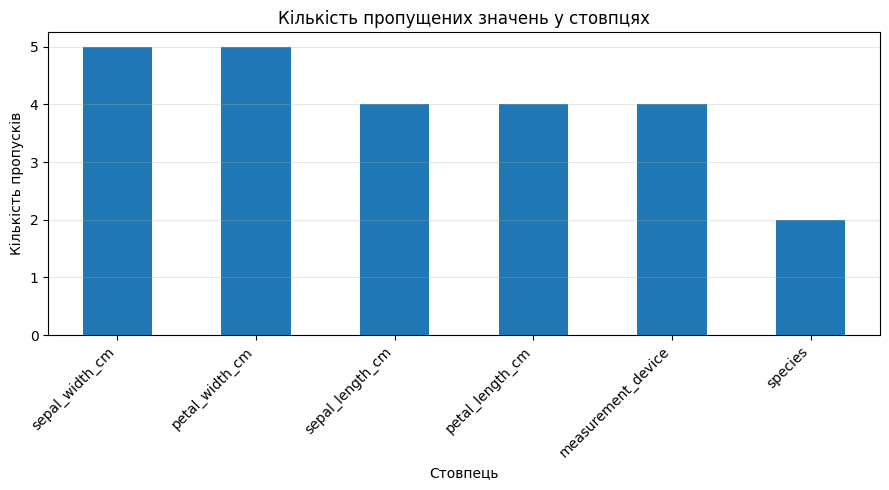

In [110]:
missing_report["missing_count"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Кількість пропущених значень у стовпцях")
plt.xlabel("Стовпець")
plt.ylabel("Кількість пропусків")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [111]:
duplicate_mask = raw_df.duplicated(keep=False)
duplicate_count = raw_df.duplicated().sum()

print("Кількість додаткових дублікатів:", duplicate_count)
print("Кількість рядків, які входять до груп дублікатів:",
      duplicate_mask.sum())


Кількість додаткових дублікатів: 4
Кількість рядків, які входять до груп дублікатів: 8


In [112]:
duplicates_table = raw_df.loc[duplicate_mask].sort_values(
    by=list(raw_df.columns)
)

display(duplicates_table)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
6,4.6,3.4,1.4,0.3,setosa,device_c
150,4.6,3.4,1.4,0.3,setosa,device_c
27,5.2,3.5,1.5,0.2,setosa,device_a
151,5.2,3.5,1.5,0.2,setosa,device_a
88,5.6,3.0,4.1,1.3,versicolor,device_a
153,5.6,3.0,4.1,1.3,versicolor,device_a
50,7.0,3.2,4.7,1.4,versicolor,device_a
152,7.0,3.2,4.7,1.4,versicolor,device_a


In [113]:
numeric_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]


In [114]:
print(raw_df[numeric_columns].dtypes)

sepal_length_cm     object
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
dtype: object


In [115]:
sepal_length_text = (
    raw_df["sepal_length_cm"]
    .astype("string")
    .str.strip()
    .str.replace(",", ".", regex=False)
)


In [116]:
sepal_length_numeric = pd.to_numeric(
    sepal_length_text,
    errors="coerce"
)


In [117]:
invalid_numeric_mask = (
    sepal_length_text.notna()
    & sepal_length_numeric.isna()
)

invalid_numeric_values = raw_df.loc[
    invalid_numeric_mask,
    ["sepal_length_cm"]
]

display(invalid_numeric_values)


,sepal_length_cm
25,unknown


In [118]:
invalid_numeric_summary = []

for column in numeric_columns:
    prepared_text = (
        raw_df[column]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )

    converted_values = pd.to_numeric(
        prepared_text,
        errors="coerce"
    )

    invalid_mask = (
        prepared_text.notna()
        & converted_values.isna()
    )

    invalid_numeric_summary.append(
        {
            "column": column,
            "invalid_count": int(invalid_mask.sum()),
            "invalid_values": raw_df.loc[
                invalid_mask,
                column
            ].astype(str).tolist()
        }
    )

invalid_numeric_summary_df = pd.DataFrame(
    invalid_numeric_summary
)

display(invalid_numeric_summary_df)


,column,invalid_count,invalid_values
0,sepal_length_cm,1,[unknown]
1,sepal_width_cm,0,[]
2,petal_length_cm,0,[]
3,petal_width_cm,0,[]


In [119]:
print("Початкові варіанти measurement_device:")

for value in raw_df["measurement_device"].dropna().unique():
    print(repr(value))


Початкові варіанти measurement_device:
'device_c'
'device_b'
'device_a'
' Device_A '
'DEVICE_B'
'device c'


In [120]:
device_counts_raw = raw_df["measurement_device"].value_counts(
    dropna=False
)

display(device_counts_raw.rename("count").to_frame())


,count
measurement_device,
device_b,58
device_a,57
device_c,32
NaN,4
Device_A,1
DEVICE_B,1
device c,1


In [121]:
clean_df = raw_df.copy()

In [122]:
rows_before_duplicates = len(clean_df)

In [123]:
clean_df = clean_df.drop_duplicates().copy()

In [124]:
rows_after_duplicates = len(clean_df)
removed_duplicates = (
    rows_before_duplicates - rows_after_duplicates
)

print("Рядків до видалення:", rows_before_duplicates)
print("Рядків після видалення:", rows_after_duplicates)
print("Видалено дублікатів:", removed_duplicates)


Рядків до видалення: 154
Рядків після видалення: 150
Видалено дублікатів: 4


In [125]:
clean_df = clean_df.reset_index(drop=True)

In [126]:
for column in numeric_columns:
    prepared_text = (
        clean_df[column]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )

    clean_df[column] = pd.to_numeric(
        prepared_text,
        errors="coerce"
    )


In [127]:
print(clean_df[numeric_columns].dtypes)

sepal_length_cm    Float64
sepal_width_cm     Float64
petal_length_cm    Float64
petal_width_cm     Float64
dtype: object


In [128]:
clean_df["measurement_device"] = (
    clean_df["measurement_device"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


In [129]:
print(
    clean_df["measurement_device"]
    .dropna()
    .value_counts()
)


measurement_device
device_b    59
device_a    55
device_c    32
Name: count, dtype: Int64


In [130]:
clean_df["species"] = (
    clean_df["species"]
    .astype("string")
    .str.strip()
    .str.lower()
)


In [131]:
valid_species = {
    "setosa",
    "versicolor",
    "virginica"
}


In [132]:
invalid_species_mask = (
    clean_df["species"].notna()
    & ~clean_df["species"].isin(valid_species)
)

print(
    "Кількість невідомих значень species:",
    invalid_species_mask.sum()
)


Кількість невідомих значень species: 0


In [133]:
clean_df.loc[
    invalid_species_mask,
    "species"
] = pd.NA


In [134]:
missing_target_count = clean_df["species"].isna().sum()

print(
    "Кількість об’єктів без цільової змінної:",
    missing_target_count
)


Кількість об’єктів без цільової змінної: 2


In [135]:
clean_df = clean_df.dropna(
    subset=["species"]
).copy()


In [136]:
clean_df = clean_df.reset_index(drop=True)

In [137]:
def extreme_outlier_mask(series, factor=3.0):
    """
    Повертає логічну маску значень, які лежать за межами
    Q1 - factor * IQR та Q3 + factor * IQR.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr

    mask = (
        (series < lower_bound)
        | (series > upper_bound)
    )

    return mask, lower_bound, upper_bound


In [138]:
anomaly_report_rows = []
anomaly_masks = {}

for column in numeric_columns:
    statistical_mask, lower_bound, upper_bound = (
        extreme_outlier_mask(
            clean_df[column],
            factor=3.0
        )
    )

    impossible_mask = clean_df[column] <= 0

    combined_mask = (
        statistical_mask
        | impossible_mask
    )

    anomaly_masks[column] = combined_mask

    anomaly_report_rows.append(
        {
            "column": column,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "impossible_count": int(
                impossible_mask.sum()
            ),
            "extreme_count": int(
                statistical_mask.sum()
            ),
            "total_flagged": int(
                combined_mask.sum()
            )
        }
    )

anomaly_report = pd.DataFrame(
    anomaly_report_rows
)

display(anomaly_report)


,column,lower_bound,upper_bound,impossible_count,extreme_count,total_flagged
0,sepal_length_cm,1.20,10.3,0,0,0
1,sepal_width_cm,1.15,5.0,0,1,1
2,petal_length_cm,-9.30,15.9,1,0,1
3,petal_width_cm,-4.20,6.3,0,1,1


In [139]:
for column, mask in anomaly_masks.items():
    if mask.any():
        print(f"\nАномальні значення у {column}:")
        display(
            clean_df.loc[
                mask,
                [column, "species"]
            ]
        )



Аномальні значення у sepal_width_cm:


,sepal_width_cm,species
55,18.0,versicolor



Аномальні значення у petal_length_cm:


,petal_length_cm,species
10,-1.0,setosa



Аномальні значення у petal_width_cm:


,petal_width_cm,species
119,9.5,virginica


In [140]:
anomaly_counts = {}

for column, mask in anomaly_masks.items():
    anomaly_counts[column] = int(mask.sum())

    clean_df.loc[
        mask,
        column
    ] = np.nan


In [141]:
missing_before_imputation = clean_df.isna().sum()

display(
    missing_before_imputation
    .rename("missing_count")
    .to_frame()
)



,missing_count
sepal_length_cm,5
sepal_width_cm,6
petal_length_cm,5
petal_width_cm,6
species,0
measurement_device,4


In [142]:
numeric_medians = clean_df[
    numeric_columns
].median()

display(
    numeric_medians
    .rename("median")
    .to_frame()
)


,median
sepal_length_cm,5.8
sepal_width_cm,3.0
petal_length_cm,4.3
petal_width_cm,1.3


In [143]:
clean_df[numeric_columns] = (
    clean_df[numeric_columns]
    .fillna(numeric_medians)
)


In [144]:
device_mode = (
    clean_df["measurement_device"]
    .mode()
    .iloc[0]
)

print(
    "Найчастіше значення measurement_device:",
    device_mode
)


Найчастіше значення measurement_device: device_b


In [145]:
clean_df["measurement_device"] = (
    clean_df["measurement_device"]
    .fillna(device_mode)
)


In [146]:
print("Кількість пропусків після обробки:")
print(clean_df.isna().sum())

Кількість пропусків після обробки:
sepal_length_cm       0
sepal_width_cm        0
petal_length_cm       0
petal_width_cm        0
species               0
measurement_device    0
dtype: int64


In [147]:
duplicates_after_cleaning = (
    clean_df.duplicated().sum()
)

print(
    "Дублікатів після очищення:",
    duplicates_after_cleaning
)


Дублікатів після очищення: 0


In [148]:
clean_df = (
    clean_df
    .drop_duplicates()
    .reset_index(drop=True)
)


In [149]:
print(
    "Дублікатів після остаточного видалення:",
    clean_df.duplicated().sum()
)


Дублікатів після остаточного видалення: 0


In [150]:
clean_quality_report = pd.DataFrame(
    {
        "data_type": clean_df.dtypes.astype(str),
        "missing_count": clean_df.isna().sum(),
        "unique_count": clean_df.nunique()
    }
)

display(clean_quality_report)


,data_type,missing_count,unique_count
sepal_length_cm,Float64,0,35
sepal_width_cm,Float64,0,23
petal_length_cm,Float64,0,42
petal_width_cm,Float64,0,22
species,string,0,3
measurement_device,string,0,3


In [151]:
display(clean_df.head(10))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,5.8,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,5.1,3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a
5,5.4,3.9,1.7,1.3,setosa,device_c
6,4.6,3.4,1.4,0.3,setosa,device_c
7,5.0,3.4,1.5,0.2,setosa,device_a
8,4.4,2.9,1.4,0.2,setosa,device_a
9,4.9,3.1,1.5,0.1,setosa,device_b


In [152]:
print("Розмір очищеної таблиці:", clean_df.shape)

Розмір очищеної таблиці: (148, 6)


## 6. Дослідницький аналіз очищених даних

Після завершення очищення аналізуються розподіли ознак, баланс
класів, взаємозв’язки між характеристиками та кореляції.


In [153]:
display(
    clean_df[numeric_columns]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,148.0,5.850676,0.797402,4.3,5.1,5.8,6.4,7.9
sepal_width_cm,148.0,3.050676,0.424023,2.0,2.8,3.0,3.3,4.4
petal_length_cm,148.0,3.731081,1.739843,1.0,1.6,4.3,5.025,6.9
petal_width_cm,148.0,1.197973,0.738952,0.1,0.3,1.3,1.8,2.5


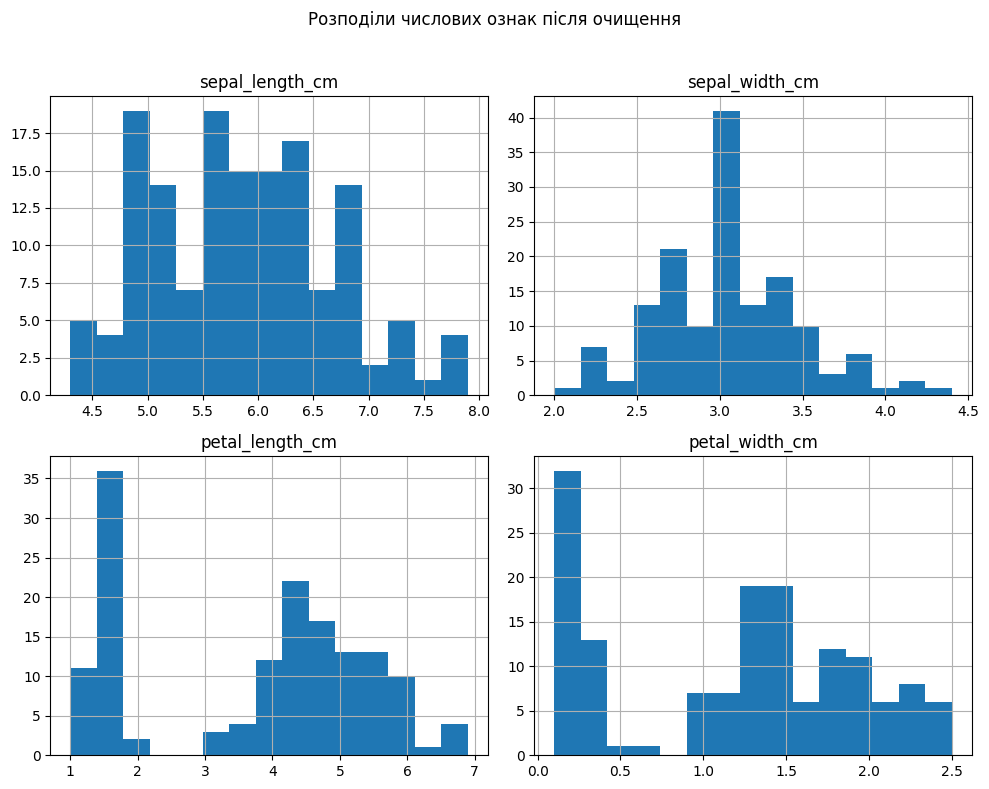

In [154]:
clean_df[numeric_columns].hist(
    bins=15,
    figsize=(10, 8)
)

plt.suptitle(
    "Розподіли числових ознак після очищення"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()


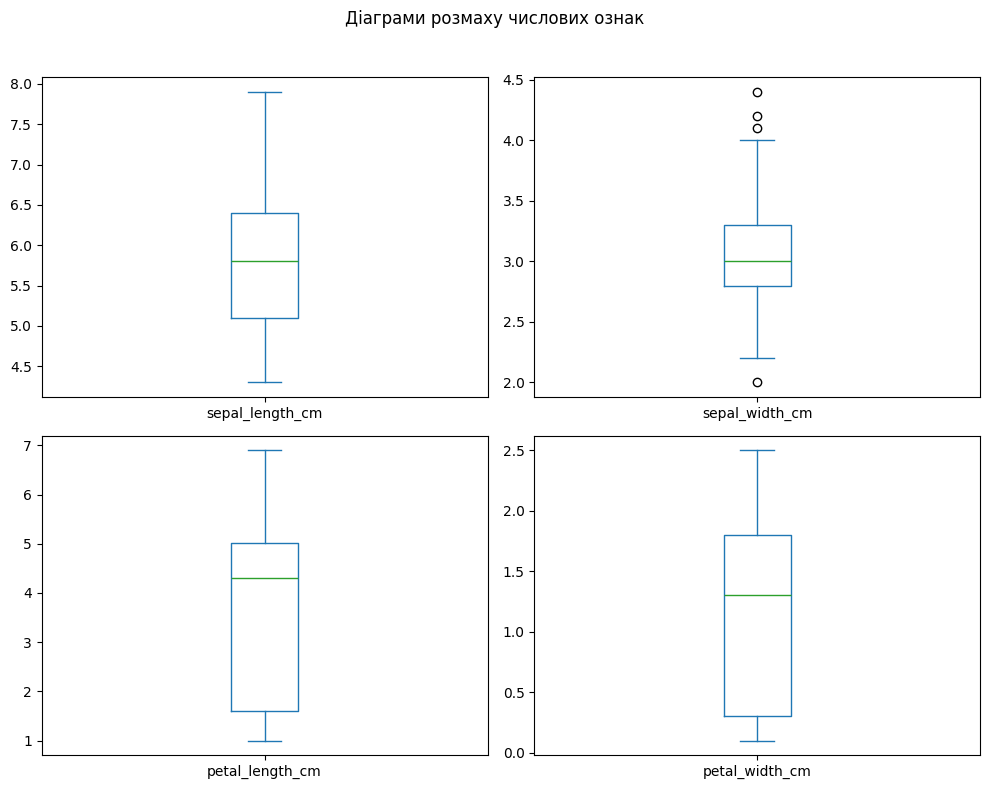

In [155]:
clean_df[numeric_columns].plot(
    kind="box",
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8),
    sharex=False,
    sharey=False
)

plt.suptitle(
    "Діаграми розмаху числових ознак"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()


In [156]:
class_distribution = pd.DataFrame(
    {
        "count": clean_df[
            "species"
        ].value_counts().sort_index(),
        "percent": (
            clean_df["species"]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    }
)

display(class_distribution)


,count,percent
species,,
setosa,50,33.78
versicolor,49,33.11
virginica,49,33.11


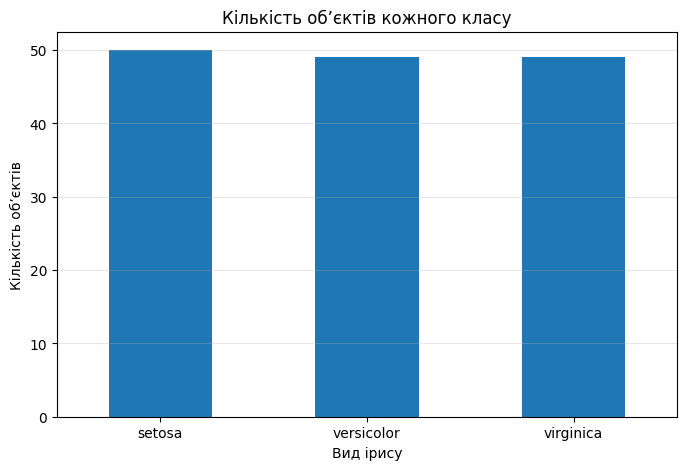

In [157]:
class_distribution["count"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Кількість об’єктів кожного класу"
)

plt.xlabel("Вид ірису")
plt.ylabel("Кількість об’єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


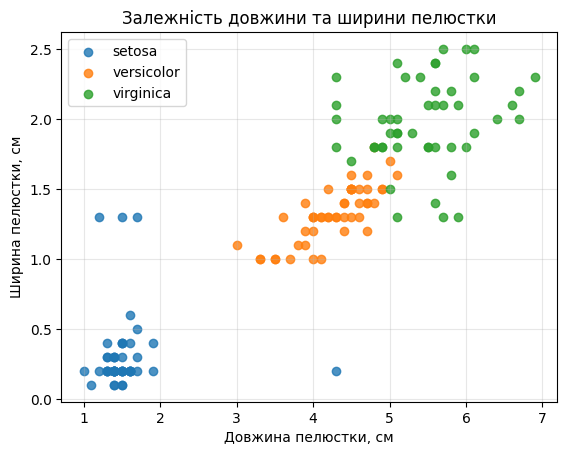

In [158]:
for species_name, group in clean_df.groupby(
    "species"
):
    plt.scatter(
        group["petal_length_cm"],
        group["petal_width_cm"],
        label=species_name,
        alpha=0.8
    )

plt.title(
    "Залежність довжини та ширини пелюстки"
)

plt.xlabel("Довжина пелюстки, см")
plt.ylabel("Ширина пелюстки, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


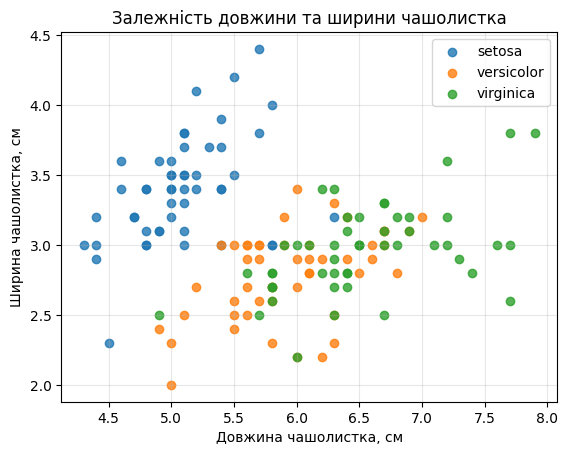

In [159]:
for species_name, group in clean_df.groupby(
    "species"
):
    plt.scatter(
        group["sepal_length_cm"],
        group["sepal_width_cm"],
        label=species_name,
        alpha=0.8
    )

plt.title(
    "Залежність довжини та ширини чашолистка"
)

plt.xlabel("Довжина чашолистка, см")
plt.ylabel("Ширина чашолистка, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


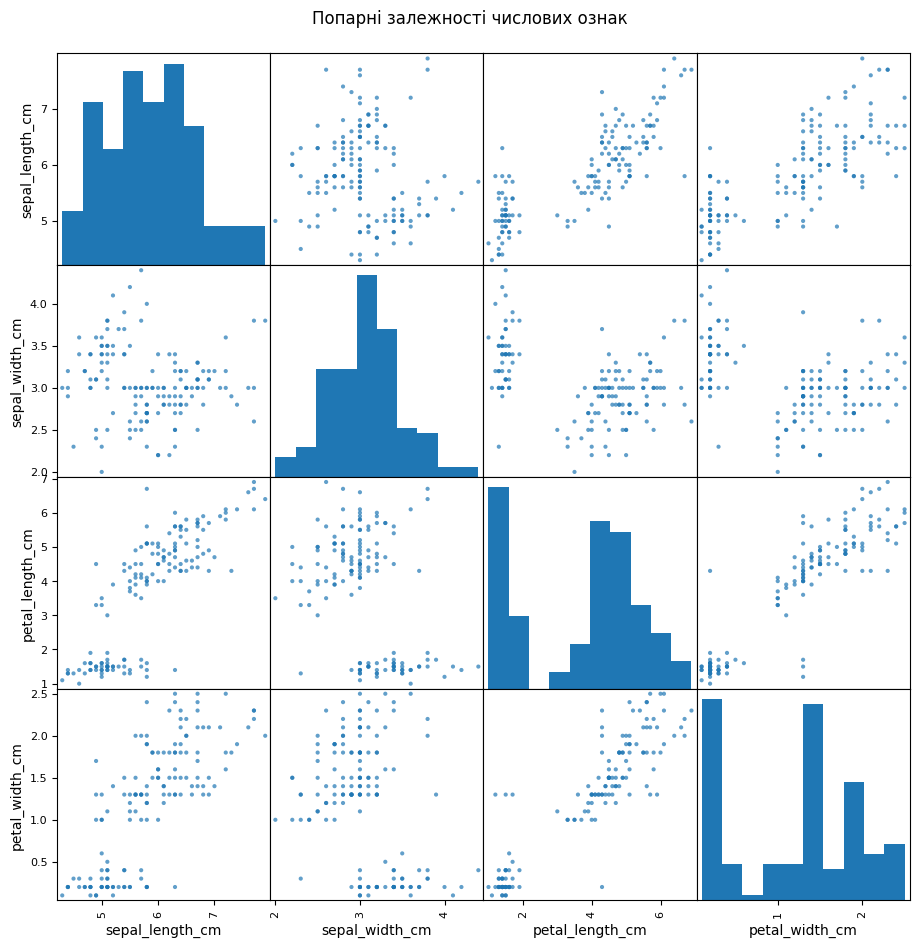

In [160]:
pd.plotting.scatter_matrix(
    clean_df[numeric_columns],
    figsize=(11, 11),
    diagonal="hist",
    alpha=0.7
)

plt.suptitle(
    "Попарні залежності числових ознак",
    y=0.92
)

plt.show()


In [161]:
correlation_matrix = (
    clean_df[numeric_columns]
    .corr()
)

display(
    correlation_matrix.round(3)
)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000,-0.105,0.819,0.760
sepal_width_cm,-0.105,1.000,-0.403,-0.355
petal_length_cm,0.819,-0.403,1.000,0.917
petal_width_cm,0.760,-0.355,0.917,1.000


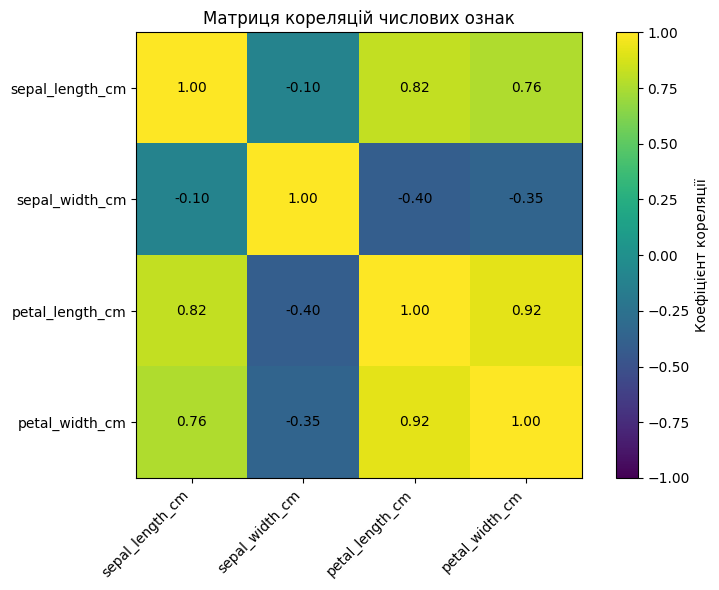

In [162]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(numeric_columns))
)

ax.set_yticks(
    range(len(numeric_columns))
)

ax.set_xticklabels(
    numeric_columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    numeric_columns
)

for row_index in range(
    len(numeric_columns)
):
    for column_index in range(
        len(numeric_columns)
    ):
        ax.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax,
    label="Коефіцієнт кореляції"
)

ax.set_title(
    "Матриця кореляцій числових ознак"
)

plt.tight_layout()
plt.show()


In [163]:
device_distribution = pd.DataFrame(
    {
        "count": clean_df[
            "measurement_device"
        ].value_counts().sort_index(),
        "percent": (
            clean_df[
                "measurement_device"
            ]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    }
)

display(device_distribution)


,count,percent
measurement_device,,
device_a,55,37.16
device_b,61,41.22
device_c,32,21.62


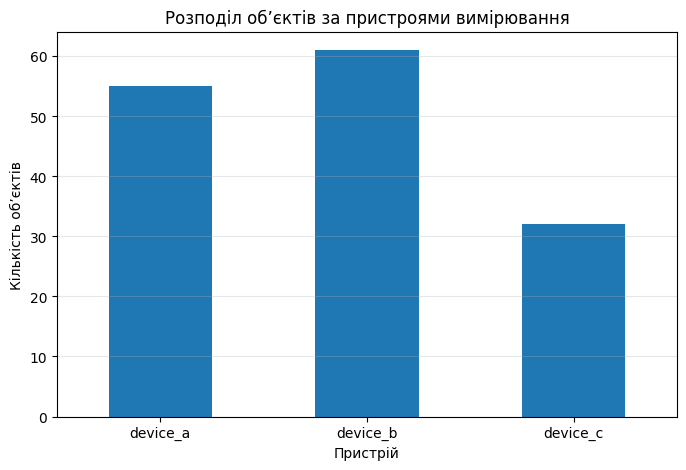

In [164]:
device_distribution["count"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Розподіл об’єктів за пристроями вимірювання"
)

plt.xlabel("Пристрій")
plt.ylabel("Кількість об’єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Кодування категоріальних ознак

Категоріальна ознака `measurement_device` кодується методом
one-hot. Цільова змінна `species` перетворюється на числові коди.


In [165]:
encoded_df = pd.get_dummies(
    clean_df,
    columns=["measurement_device"],
    dtype=int
)

display(encoded_df.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,setosa,0,0,1
1,5.8,3.0,1.4,0.2,setosa,0,1,0
2,4.7,3.2,1.3,0.2,setosa,0,0,1
3,5.1,3.1,1.5,0.2,setosa,0,1,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


In [166]:
print("Стовпці після кодування:")

for column in encoded_df.columns:
    print("-", column)


Стовпці після кодування:
- sepal_length_cm
- sepal_width_cm
- petal_length_cm
- petal_width_cm
- species
- measurement_device_device_a
- measurement_device_device_b
- measurement_device_device_c


In [167]:
class_mapping = {
    "setosa": 0,
    "versicolor": 1,
    "virginica": 2
}


In [168]:
encoded_df["species_code"] = (
    encoded_df["species"]
    .map(class_mapping)
)


In [169]:
display(
    encoded_df[
        ["species", "species_code"]
    ]
    .drop_duplicates()
    .sort_values("species_code")
)


,species,species_code
0,setosa,0
50,versicolor,1
99,virginica,2


In [170]:
X = encoded_df.drop(
    columns=[
        "species",
        "species_code"
    ]
)

y = encoded_df["species_code"]


In [171]:
print("Розмір X:", X.shape)
print("Розмір y:", y.shape)


Розмір X: (148, 7)
Розмір y: (148,)


In [172]:
display(X.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,0,0,1
1,5.8,3.0,1.4,0.2,0,1,0
2,4.7,3.2,1.3,0.2,0,0,1
3,5.1,3.1,1.5,0.2,0,1,0
4,5.0,3.6,1.4,0.2,1,0,0


In [173]:
display(y.head())


,species_code
0,0
1,0
2,0
3,0
4,0


## 8. Формування навчальної й тестової вибірок

Для тестування виділяється 20 % об’єктів. Використовується
стратифікація, щоб зберегти приблизно однакові частки класів.
Примітка. У межах цієї практичної роботи поділ виконується після очищення всього набору даних. Отримані X_train і X_test призначені для демонстрації структури навчальної та тестової вибірок, збереження співвідношення класів і підготовки файлів для наступної роботи. На цьому етапі X_test ще не слід використовувати для остаточної незалежної оцінки якості моделі, оскільки параметри очищення та заповнення пропусків було визначено до розбиття даних.


In [174]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)


In [175]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (118, 7)
X_test: (30, 7)
y_train: (118,)
y_test: (30,)


In [176]:
reverse_class_mapping = {
    value: key
    for key, value in class_mapping.items()
}


In [177]:
train_counts = (
    y_train
    .value_counts()
    .sort_index()
)

test_counts = (
    y_test
    .value_counts()
    .sort_index()
)

class_split_report = pd.DataFrame(
    {
        "train_count": train_counts,
        "test_count": test_counts
    }
)

class_split_report.index = [
    reverse_class_mapping[index]
    for index in class_split_report.index
]

class_split_report["train_percent"] = (
    class_split_report["train_count"]
    / class_split_report["train_count"].sum()
    * 100
).round(2)

class_split_report["test_percent"] = (
    class_split_report["test_count"]
    / class_split_report["test_count"].sum()
    * 100
).round(2)

display(class_split_report)


,train_count,test_count,train_percent,test_percent
setosa,40,10,33.90,33.33
versicolor,39,10,33.05,33.33
virginica,39,10,33.05,33.33


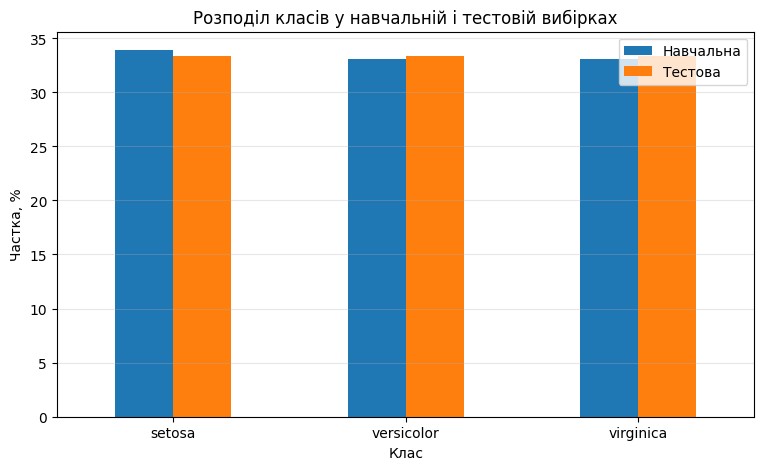

In [178]:
class_split_report[
    ["train_percent", "test_percent"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Розподіл класів у навчальній і тестовій вибірках"
)

plt.xlabel("Клас")
plt.ylabel("Частка, %")
plt.xticks(rotation=0)
plt.legend(
    ["Навчальна", "Тестова"]
)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [179]:
_, _, y_train_random, y_test_random = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=7
    )
)


In [180]:
random_split_report = pd.DataFrame(
    {
        "train_percent": (
            y_train_random
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        ),
        "test_percent": (
            y_test_random
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    }
)

random_split_report.index = [
    reverse_class_mapping[index]
    for index in random_split_report.index
]

display(random_split_report)


,train_percent,test_percent
setosa,36.44,23.33
versicolor,31.36,40.00
virginica,32.20,36.67


In [181]:
preprocessing_summary = pd.DataFrame(
    [
        {
            "stage": "Початковий пошкоджений набір",
            "row_count": len(raw_df),
            "missing_count": int(
                raw_df.isna().sum().sum()
            ),
            "duplicate_count": int(
                raw_df.duplicated().sum()
            )
        },
        {
            "stage": "Після видалення дублікатів",
            "row_count": rows_after_duplicates,
            "missing_count": None,
            "duplicate_count": 0
        },
        {
            "stage": "Після очищення",
            "row_count": len(clean_df),
            "missing_count": int(
                clean_df.isna().sum().sum()
            ),
            "duplicate_count": int(
                clean_df.duplicated().sum()
            )
        },
        {
            "stage": "Навчальна вибірка",
            "row_count": len(X_train),
            "missing_count": int(
                X_train.isna().sum().sum()
            ),
            "duplicate_count": int(
                X_train.duplicated().sum()
            )
        },
        {
            "stage": "Тестова вибірка",
            "row_count": len(X_test),
            "missing_count": int(
                X_test.isna().sum().sum()
            ),
            "duplicate_count": int(
                X_test.duplicated().sum()
            )
        }
    ]
)

display(preprocessing_summary)


,stage,row_count,missing_count,duplicate_count
0,Початковий пошкоджений набір,154,24.0,4
1,Після видалення дублікатів,150,NaN,0
2,Після очищення,148,0.0,0
3,Навчальна вибірка,118,0.0,0
4,Тестова вибірка,30,0.0,0


In [182]:
clean_df.to_csv(
    CLEANED_PATH,
    index=False
)

print(
    "Очищений набір збережено:",
    CLEANED_PATH
)


Очищений набір збережено: /content/drive/MyDrive/pattern-recognition-practice/data/processed/iris_cleaned.csv


In [183]:
X_train.to_csv(
    X_TRAIN_PATH,
    index=False
)

X_test.to_csv(
    X_TEST_PATH,
    index=False
)


In [184]:
y_train.rename(
    "species_code"
).to_csv(
    Y_TRAIN_PATH,
    index=False
)

y_test.rename(
    "species_code"
).to_csv(
    Y_TEST_PATH,
    index=False
)


In [185]:
preprocessing_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print(
    "Звіт збережено:",
    SUMMARY_PATH
)



Звіт збережено: /content/drive/MyDrive/pattern-recognition-practice/reports/preprocessing_summary.csv


In [186]:
with open(
    CLASS_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        class_mapping,
        file,
        ensure_ascii=False,
        indent=4
    )

print(
    "Словник класів збережено:",
    CLASS_MAPPING_PATH
)


Словник класів збережено: /content/drive/MyDrive/pattern-recognition-practice/reports/class_mapping.json


In [187]:
output_files = [
    DIRTY_PATH,
    CLEANED_PATH,
    X_TRAIN_PATH,
    X_TEST_PATH,
    Y_TRAIN_PATH,
    Y_TEST_PATH,
    SUMMARY_PATH,
    CLASS_MAPPING_PATH
]

for path in output_files:
    print(
        path.name,
        "–",
        "створено" if path.exists()
        else "відсутній"
    )



iris_dirty.csv – створено
iris_cleaned.csv – створено
X_train.csv – створено
X_test.csv – створено
y_train.csv – створено
y_test.csv – створено
preprocessing_summary.csv – створено
class_mapping.json – створено


In [188]:
assert clean_df.isna().sum().sum() == 0, (
    "В очищеній таблиці залишилися пропуски."
)

assert clean_df.duplicated().sum() == 0, (
    "В очищеній таблиці залишилися дублікати."
)

assert set(clean_df["species"].unique()) == {
    "setosa",
    "versicolor",
    "virginica"
}, "Набір класів не відповідає очікуваному."

assert set(
    clean_df["measurement_device"].unique()
) == {
    "device_a",
    "device_b",
    "device_c"
}, "Категорії пристроїв очищено неправильно."

assert all(
    pd.api.types.is_numeric_dtype(
        clean_df[column]
    )
    for column in numeric_columns
), "Не всі числові стовпці мають числовий тип."

assert (
    clean_df[numeric_columns] > 0
).all().all(), (
    "Залишилися фізично неможливі значення."
)

assert len(X_train) + len(X_test) == len(X), (
    "Кількість об’єктів після розбиття змінилася."
)

assert list(X_train.columns) == list(X_test.columns), (
    "Стовпці train і test не збігаються."
)

assert set(y_train.unique()) == {0, 1, 2}, (
    "У навчальній вибірці відсутній один із класів."
)

assert set(y_test.unique()) == {0, 1, 2}, (
    "У тестовій вибірці відсутній один із класів."
)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print(
    "Усі основні перевірки виконано успішно."
)


Усі основні перевірки виконано успішно.


# Висновки

Під час виконання практичної роботи було проведено дослідницький аналіз і підготовку набору даних Iris до навчання моделей машинного навчання.

Для відпрацювання методів очищення було створено контрольовано пошкоджену версію набору, яка містила пропущені значення, дублікати, текстові записи у числовому стовпці, неузгоджені назви категорій і аномальні числові значення.

Під час аудиту було визначено типи даних, кількість пропусків, кількість унікальних значень і повні дублікати. Числові стовпці було перетворено до правильних типів, а некоректні текстові записи перетворено на пропущені значення.

Назви категорій пристроїв було уніфіковано. Об’єкти без відомого значення цільової змінної видалено. Фізично неможливі та екстремальні значення було виявлено за допомогою логічних правил і міжквартильного розмаху.

Пропуски числових ознак заповнено медіанами, а пропуски категоріальної ознаки – модою. Після очищення в таблиці не залишилося пропущених значень і повних дублікатів.

Було побудовано гістограми, діаграми розмаху, діаграми залежностей між ознаками, розподіл класів і матрицю кореляцій. Встановлено, що довжина та ширина пелюстки мають сильний взаємозв’язок і добре відокремлюють клас setosa.

Категоріальну ознаку measurement_device було закодовано методом
one-hot, а цільову змінну species перетворено на числові коди.
Після цього набір було розділено на матрицю ознак X і цільову змінну y.
Сформовано навчальну та тестову вибірки у співвідношенні 80 % і 20 %. Завдяки стратифікованому розбиттю в обох вибірках збережено близьке співвідношення трьох класів.
У цій роботі розбиття виконано після очищення та кодування всього набору даних як навчальне спрощення. Тому сформована тестова вибірка демонструє принцип поділу даних і стратифікації, але ще не використовується для остаточного незалежного оцінювання моделі. У наступній практичній роботі параметри заповнення пропусків і кодування категорій визначатимуться лише за навчальною вибіркою за допомогою конвеєра Pipeline

Очищений набір, навчальна і тестова вибірки, словник класів та звіт про підготовку було збережено для використання в наступних практичних роботах.
